# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### CSV Load

In [2]:
df = pd.read_csv("C:/Users/anil1/OneDrive/Desktop/MPI/6/shopping_behavior.csv")

print("Dataset successfully loaded!")
print("Rows and Columns:", df.shape)

Dataset successfully loaded!
Rows and Columns: (3900, 18)


#### ->  5 Rows 

In [3]:
df.head()

,Customer ID,Age,Gender,Location,Subscription Status,Item Purchased,Category,Purchase Amount (USD),Season,Size,Color,Discount Applied,Promo Code Used,Previous Purchases,Frequency of Purchases,Review Rating,Shipping Type,Payment Method
0,1,32,Male,Arizona,No,Pants,Clothing,35.64,Winter,XL,Blue,Yes,No,0,Quarterly,4.82,Express,Debit Card
1,2,50,Male,Washington,Yes,Jewelry,Accessories,15.00,Winter,XL,Blue,No,No,1,Weekly,4.23,Standard,Cash
2,3,56,Female,Ohio,No,Sandals,Footwear,47.59,Winter,L,Blue,No,No,0,Quarterly,3.60,Express,Debit Card
3,4,35,Female,Arizona,No,Pants,Clothing,73.57,Winter,S,Gray,No,No,1,Annually,3.66,Express,Credit Card
4,5,62,Female,Montana,No,Sweater,Clothing,71.24,Summer,L,Purple,Yes,No,0,Quarterly,4.19,Express,Venmo


#### ->  Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Location                3900 non-null   object 
 4   Subscription Status     3900 non-null   object 
 5   Item Purchased          3900 non-null   object 
 6   Category                3900 non-null   object 
 7   Purchase Amount (USD)   3900 non-null   float64
 8   Season                  3900 non-null   object 
 9   Size                    3900 non-null   object 
 10  Color                   3900 non-null   object 
 11  Discount Applied        3900 non-null   object 
 12  Promo Code Used         3900 non-null   object 
 13  Previous Purchases      3900 non-null   int64  
 14  Frequency of Purchases  3900 non-null   

In [5]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Location', 'Subscription Status',
       'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Season', 'Size',
       'Color', 'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Frequency of Purchases', 'Review Rating', 'Shipping Type',
       'Payment Method'],
      dtype='object')

#### -> Missing Values

In [6]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Location                  0
Subscription Status       0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Season                    0
Size                      0
Color                     0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Frequency of Purchases    0
Review Rating             0
Shipping Type             0
Payment Method            0
dtype: int64

#### -> Statistical Summary

In [7]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Previous Purchases,Review Rating
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,43.906923,59.397146,17.473077,3.750497
std,1125.977353,15.511648,20.179329,7.828407,0.499466
min,1.000000,18.000000,15.000000,0.000000,1.520000
25%,975.750000,30.000000,45.600000,12.000000,3.420000
50%,1950.500000,44.000000,59.270000,18.000000,3.750000
75%,2925.250000,57.000000,73.255000,24.000000,4.090000
max,3900.000000,70.000000,110.000000,30.000000,5.000000


#### -> Column Names

In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

df.columns

Index(['customer_id', 'age', 'gender', 'location', 'subscription_status',
       'item_purchased', 'category', 'purchase_amount_usd', 'season', 'size',
       'color', 'discount_applied', 'promo_code_used', 'previous_purchases',
       'frequency_of_purchases', 'review_rating', 'shipping_type',
       'payment_method'],
      dtype='object')

#### -> Numeric Columns

In [9]:
numeric_columns = [
    "age",
    "purchase_amount_usd",
    "previous_purchases",
    "review_rating"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_columns].dtypes)

age                      int64
purchase_amount_usd    float64
previous_purchases       int64
review_rating          float64
dtype: object


#### -> Review Rating me Missing Values

In [10]:
print("Missing Review Ratings:")
print(df["review_rating"].isnull().sum())

Missing Review Ratings:
0


#### -> Category-wise Median se Missing Value bharna

In [11]:
df["review_rating"] = (
    df.groupby("category")["review_rating"]
      .transform(lambda x: x.fillna(x.median()))
)

print("Remaining Missing Review Ratings:")
print(df["review_rating"].isnull().sum())

Remaining Missing Review Ratings:
0


#### -> Age Group

In [12]:
def create_age_group(age):
    if age < 25:
        return "Young Adult"
    elif age < 40:
        return "Adult"
    elif age < 60:
        return "Middle-aged"
    else:
        return "Senior"

df["age_group"] = df["age"].apply(create_age_group)

df[["age", "age_group"]].head(10)

,age,age_group
0,32,Adult
1,50,Middle-aged
2,56,Middle-aged
3,35,Adult
4,62,Senior
5,39,Adult
6,56,Middle-aged
7,28,Adult
8,61,Senior
9,66,Senior


#### -> Purchase Frequency ko Days me badlna

In [13]:
frequency_days = {
    "Daily": 1,
    "Weekly": 7,
    "Bi-Weekly": 14,
    "Fortnightly": 14,
    "Monthly": 30,
    "Quarterly": 90,
    "Every 3 Months": 90,
    "Annually": 365
}

df["purchase_frequency_days"] = (
    df["frequency_of_purchases"]
    .map(frequency_days)
)

df[["frequency_of_purchases", "purchase_frequency_days"]].head()

,frequency_of_purchases,purchase_frequency_days
0,Quarterly,90
1,Weekly,7
2,Quarterly,90
3,Annually,365
4,Quarterly,90


#### -> Duplicate Check

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### -> Duplicate delete

In [15]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (3900, 20)


#### -> Promo Code Column delete

In [16]:
if "promo_code_used" in df.columns:
    df = df.drop(columns=["promo_code_used"])

print(df.columns)

Index(['customer_id', 'age', 'gender', 'location', 'subscription_status',
       'item_purchased', 'category', 'purchase_amount_usd', 'season', 'size',
       'color', 'discount_applied', 'previous_purchases',
       'frequency_of_purchases', 'review_rating', 'shipping_type',
       'payment_method', 'age_group', 'purchase_frequency_days'],
      dtype='object')


#### -> Customer Segmentation

In [17]:
def customer_segment(purchases):
    if purchases <= 2:
        return "New"
    elif purchases <= 10:
        return "Returning"
    else:
        return "Loyal"

df["customer_segment"] = df["previous_purchases"].apply(customer_segment)

df["customer_segment"].value_counts()

customer_segment
Loyal        3116
Returning     701
New            83
Name: count, dtype: int64

#### -> Gender ke anusar Revenue

In [18]:
gender_revenue = (
    df.groupby("gender")["purchase_amount_usd"]
      .sum()
      .sort_values(ascending=False)
)

gender_revenue

gender
Male      158683.04
Female     72965.83
Name: purchase_amount_usd, dtype: float64

#### -> Discount Users

In [19]:
discount_users = df[
    (df["discount_applied"] == "Yes") &
    (df["purchase_amount_usd"] > df["purchase_amount_usd"].median())
]

print("High-spending discount users:", len(discount_users))

High-spending discount users: 464


#### -> Top 5 Products by Rating

In [20]:
top_5_products = (
    df.groupby("item_purchased")["review_rating"]
      .mean()
      .sort_values(ascending=False)
      .head(5)
)

top_5_products

item_purchased
Blouse     3.847733
Pants      3.789375
Sandals    3.785475
Skirt      3.780963
Jewelry    3.776589
Name: review_rating, dtype: float64

#### -> Shipping Type Comparison

In [21]:
shipping_analysis = (
    df.groupby("shipping_type")["purchase_amount_usd"]
      .agg(["count", "mean", "sum"])
      .sort_values("mean", ascending=False)
)

shipping_analysis

,count,mean,sum
shipping_type,,,
Express,2914,59.571146,173590.32
Standard,986,58.882911,58058.55


#### -> Subscription Analysis

In [22]:
subscription_analysis = (
    df.groupby("subscription_status")["purchase_amount_usd"]
      .agg(["count", "mean", "sum"])
)

subscription_analysis

,count,mean,sum
subscription_status,,,
No,2849,59.805609,170386.18
Yes,1051,58.289905,61262.69


#### -> Category Analysis

In [23]:
category_analysis = (
    df.groupby("category")["purchase_amount_usd"]
      .agg(["count", "mean", "sum"])
      .sort_values("sum", ascending=False)
)

category_analysis

,count,mean,sum
category,,,
Clothing,1507,59.669900,89922.54
Accessories,1003,59.856152,60035.72
Footwear,812,58.379495,47404.15
Outerwear,578,59.319135,34286.46


#### -> Age Group Analysis

In [24]:
age_analysis = (
    df.groupby("age_group")["purchase_amount_usd"]
      .agg(["count", "mean", "sum"])
)

age_analysis

,count,mean,sum
age_group,,,
Adult,1086,59.525046,64644.20
Middle-aged,1454,59.401534,86369.83
Senior,812,59.245788,48107.58
Young Adult,548,59.356314,32527.26


#### -> Customer Segmentation

In [25]:
segment_analysis = (
    df.groupby("customer_segment")["purchase_amount_usd"]
      .agg(["count", "mean", "sum"])
)

segment_analysis

,count,mean,sum
customer_segment,,,
Loyal,3116,59.448758,185242.33
New,83,56.596145,4697.48
Returning,701,59.499372,41709.06


#### -> Simple Visualization

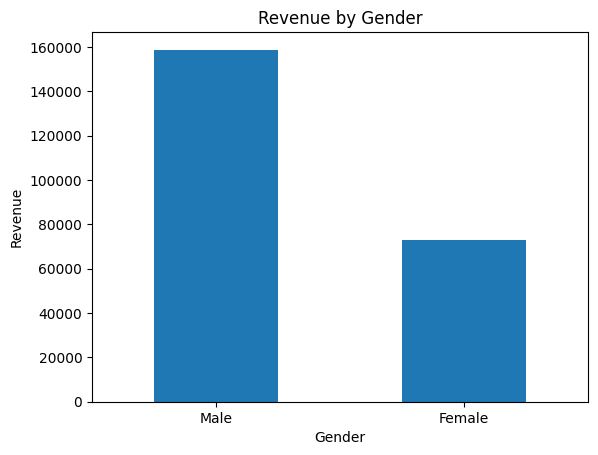

In [26]:
gender_revenue.plot(kind="bar")

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

#### -> Category Revenue Chart

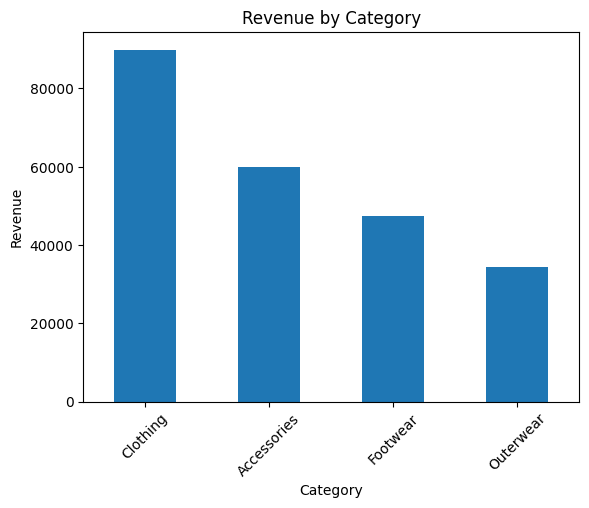

In [27]:
category_revenue = (
    df.groupby("category")["purchase_amount_usd"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

#### -> Customer Segment Chart

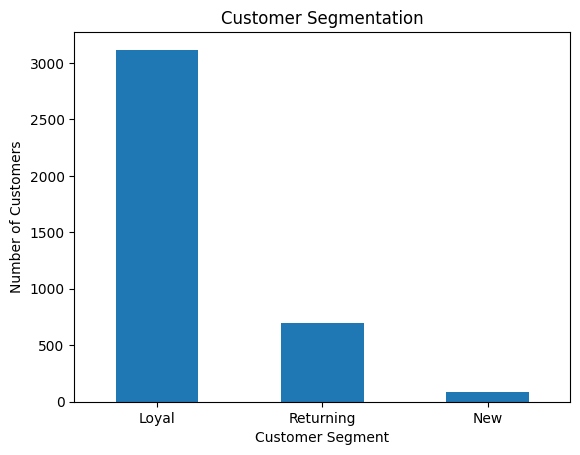

In [28]:
df["customer_segment"].value_counts().plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

#### -> Final Dataset

In [29]:
df.head()

,customer_id,age,gender,location,subscription_status,item_purchased,category,purchase_amount_usd,season,size,color,discount_applied,previous_purchases,frequency_of_purchases,review_rating,shipping_type,payment_method,age_group,purchase_frequency_days,customer_segment
0,1,32,Male,Arizona,No,Pants,Clothing,35.64,Winter,XL,Blue,Yes,0,Quarterly,4.82,Express,Debit Card,Adult,90,New
1,2,50,Male,Washington,Yes,Jewelry,Accessories,15.00,Winter,XL,Blue,No,1,Weekly,4.23,Standard,Cash,Middle-aged,7,New
2,3,56,Female,Ohio,No,Sandals,Footwear,47.59,Winter,L,Blue,No,0,Quarterly,3.60,Express,Debit Card,Middle-aged,90,New
3,4,35,Female,Arizona,No,Pants,Clothing,73.57,Winter,S,Gray,No,1,Annually,3.66,Express,Credit Card,Adult,365,New
4,5,62,Female,Montana,No,Sweater,Clothing,71.24,Summer,L,Purple,Yes,0,Quarterly,4.19,Express,Venmo,Senior,90,New


#### -> Cleaned CSV Save karna

In [30]:
df.to_csv("cleaned_customer_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
